In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")


In [8]:
# STEP 1: Load the Datasets

sentiment_df = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\Primetrade Assignment\sentiment_data.csv.csv")
trader_df = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\Primetrade Assignment\trader_data.csv.csv")

sentiment_df.columns = sentiment_df.columns.str.strip()
trader_df.columns = trader_df.columns.str.strip()

print("Files loaded successfully!")
print("Sentiment columns:", sentiment_df.columns.tolist())
print("Trader columns:", trader_df.columns.tolist())

Files loaded successfully!
Sentiment columns: ['timestamp', 'value', 'classification', 'date']
Trader columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [9]:
# STEP 2: Data Cleaning & Preprocessing

if 'date' in sentiment_df.columns:
    sentiment_df = sentiment_df.rename(columns={'date': 'Date'})
    
if 'Date' in sentiment_df.columns:
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.date
else:
    print("WARNING: Could not find 'Date' column in sentiment dataset.")

if 'Timestamp' in trader_df.columns:
    trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp'], unit='ms') 
    trader_df['Date'] = trader_df['datetime'].dt.date
else:
    print("WARNING: Could not find 'Timestamp' column in trader dataset.")

if 'Closed PnL' in trader_df.columns:
    trader_df['Closed PnL'] = trader_df['Closed PnL'].fillna(0)


In [12]:
# STEP 3: Merging the Datasets

df = pd.merge(trader_df, sentiment_df, on='Date', how='left')

if 'classification' in df.columns:
    df = df.dropna(subset=['classification'])
    print(f"Success! Data merged. Total rows available for analysis: {len(df)}")
else:
    print("Merge worked, but couldn't find 'classification' in the sentiment file.")


Success! Data merged. Total rows available for analysis: 184263


--- Overall Trader Performance by Market Sentiment ---
                     mean           sum   count
classification                                 
Extreme Greed   25.418772  1.769655e+05    6962
Fear            50.047622  6.699925e+06  133871
Greed           87.894859  3.189617e+06   36289
Neutral         22.229713  1.587424e+05    7141


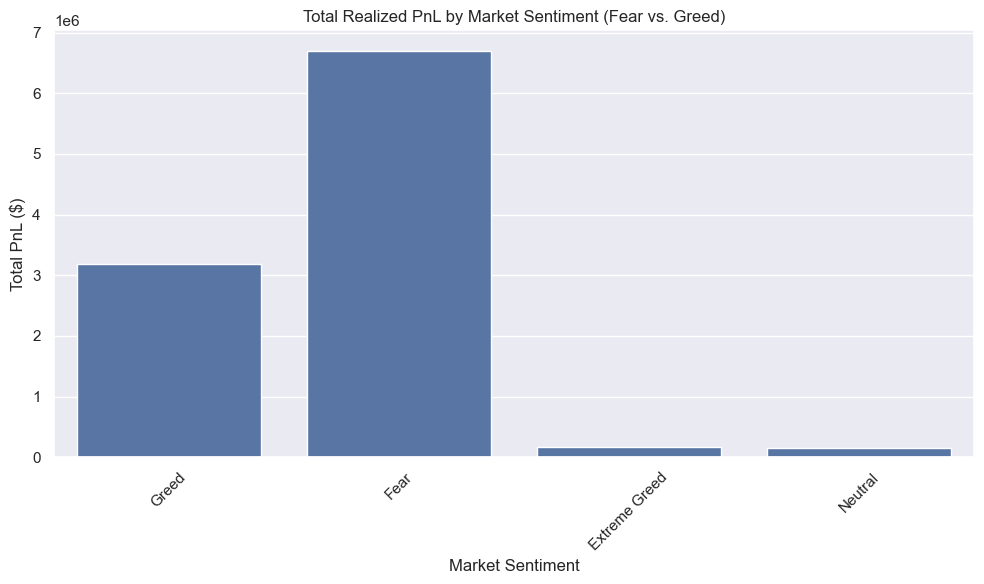

In [13]:
# STEP 4: Exploratory Data Analysis (EDA)

print("--- Overall Trader Performance by Market Sentiment ---")
sentiment_performance = df.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count'])
print(sentiment_performance)

plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Closed PnL', data=df, estimator=sum, errorbar=None)
plt.title('Total Realized PnL by Market Sentiment (Fear vs. Greed)')
plt.ylabel('Total PnL ($)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



--- Trade Direction (Buy/Sell) count by Market Sentiment ---
Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


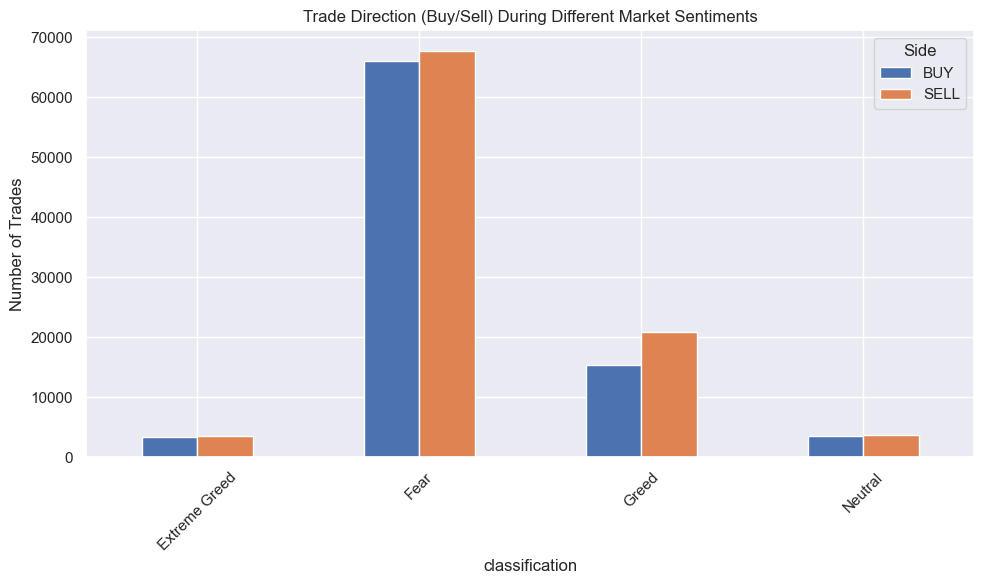


--- Average Trade Size (USD) by Market Sentiment ---
classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


In [14]:
# STEP 5: Uncovering Hidden Patterns

if 'Side' in df.columns:
    side_sentiment = df.groupby(['classification', 'Side']).size().unstack().fillna(0)
    print("\n--- Trade Direction (Buy/Sell) count by Market Sentiment ---")
    print(side_sentiment)
    
    side_sentiment.plot(kind='bar', stacked=False, figsize=(10, 6))
    plt.title('Trade Direction (Buy/Sell) During Different Market Sentiments')
    plt.ylabel('Number of Trades')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if 'Size USD' in df.columns:
    size_sentiment = df.groupby('classification')['Size USD'].mean()
    print("\n--- Average Trade Size (USD) by Market Sentiment ---")
    print(size_sentiment)
    


--- Top 5% Traders' Behavior (Buy/Sell Ratio) by Sentiment ---
Side                 BUY      SELL
classification                    
Extreme Greed   0.491873  0.508127
Fear            0.471138  0.528862
Greed           0.275638  0.724362
Neutral         0.620207  0.379793

--- Trade Win Rate (%) by Market Sentiment ---
classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: is_profitable, dtype: float64


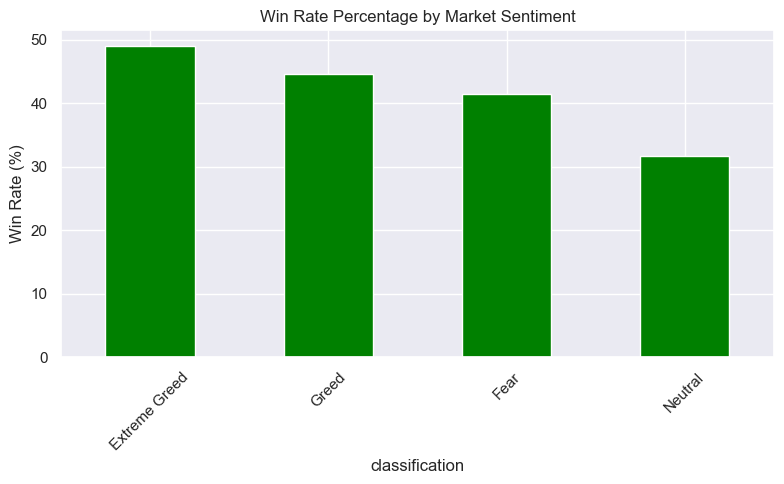

In [15]:
# STEP 6: Smart Money Behavior & Win Rates

account_pnl = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
top_traders = account_pnl.head(int(len(account_pnl) * 0.05)).index

df['is_top_trader'] = df['Account'].isin(top_traders)

if 'Side' in df.columns:
    top_trader_sentiment = df[df['is_top_trader']].groupby('classification')['Side'].value_counts(normalize=True).unstack()
    print("\n--- Top 5% Traders' Behavior (Buy/Sell Ratio) by Sentiment ---")
    print(top_trader_sentiment)

df['is_profitable'] = df['Closed PnL'] > 0
win_rate = df.groupby('classification')['is_profitable'].mean() * 100

print("\n--- Trade Win Rate (%) by Market Sentiment ---")
print(win_rate)

win_rate.sort_values(ascending=False).plot(kind='bar', color='green', figsize=(8, 5))
plt.title('Win Rate Percentage by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
